# 07 — Model Interpretability & Explainability
Phase 11. Interpretability matters here because a fraud-risk model shapes decisions about real people's claims — investigators, compliance, and (indirectly) customers all need to understand *why* a claim was scored the way it was, not just trust an opaque number.

In [1]:
import sys, warnings, json
sys.path.append('../src')
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.model_selection import train_test_split

from preprocessing import (load_raw_data, basic_clean, encode_target, get_column_groups,
                            build_preprocessing_pipeline, get_feature_names)
from feature_engineering import engineer_features

RANDOM_STATE = 42
DROP = ["policy_number","insured_zip","incident_location","policy_bind_date","incident_date"]

model = joblib.load('../models/fraud_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')
with open('../models/feature_names.json') as f:
    feature_names = json.load(f)
with open('../models/high_value_threshold.json') as f:
    threshold = json.load(f)['high_value_claim_threshold']

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df); df = encode_target(df)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['fraud_reported'], random_state=RANDOM_STATE)
test_fe, _ = engineer_features(test_df.reset_index(drop=True), high_value_threshold=threshold)
test_fe = test_fe.drop(columns=[c for c in DROP if c in test_fe.columns])
y_test = test_fe.pop('fraud_reported')
X_test = preprocessor.transform(test_fe)
if hasattr(X_test, 'toarray'): X_test = X_test.toarray()
print("Loaded final model + test set:", X_test.shape)

Loaded final model + test set: (200, 174)


## Global feature importance (native, from the Gradient Boosting model)

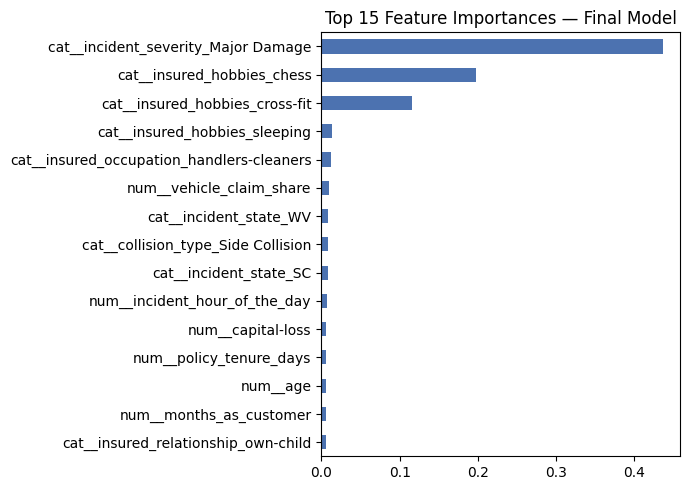

cat__incident_severity_Major Damage          0.436321
cat__insured_hobbies_chess                   0.197441
cat__insured_hobbies_cross-fit               0.115572
cat__insured_hobbies_sleeping                0.013046
cat__insured_occupation_handlers-cleaners    0.012879
num__vehicle_claim_share                     0.009638
cat__incident_state_WV                       0.009093
cat__collision_type_Side Collision           0.008495
cat__incident_state_SC                       0.008014
num__incident_hour_of_the_day                0.007447
num__capital-loss                            0.006173
num__policy_tenure_days                      0.005952
num__age                                     0.005776
num__months_as_customer                      0.005679
cat__insured_relationship_own-child          0.005516
dtype: float64

In [2]:
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
top15 = importances.head(15)
fig, ax = plt.subplots(figsize=(7,5))
top15.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Feature Importances — Final Model')
plt.tight_layout(); plt.show()
top15

**Observation:** `incident_severity_Major Damage` dominates by a wide margin, consistent with the EDA finding in notebook 02. Two hobby categories (`chess`, `cross-fit`) also rank surprisingly high — again consistent with notebook 02's flag that hobby-fraud association here is very likely a **dataset artifact / spurious proxy**, not a real causal driver.

**Explicit caution (do not over-claim):** feature importance tells us the model *relied on* a feature to reduce prediction error on this dataset — it does **not** tell us that feature *causes* fraud, and it does not validate that the pattern would hold on a different, real-world population. This is exactly why Phase 15 (governance) flags hobby as a variable that should not be used to target individuals in a real deployment without independent validation.

## SHAP — per-feature contribution and direction

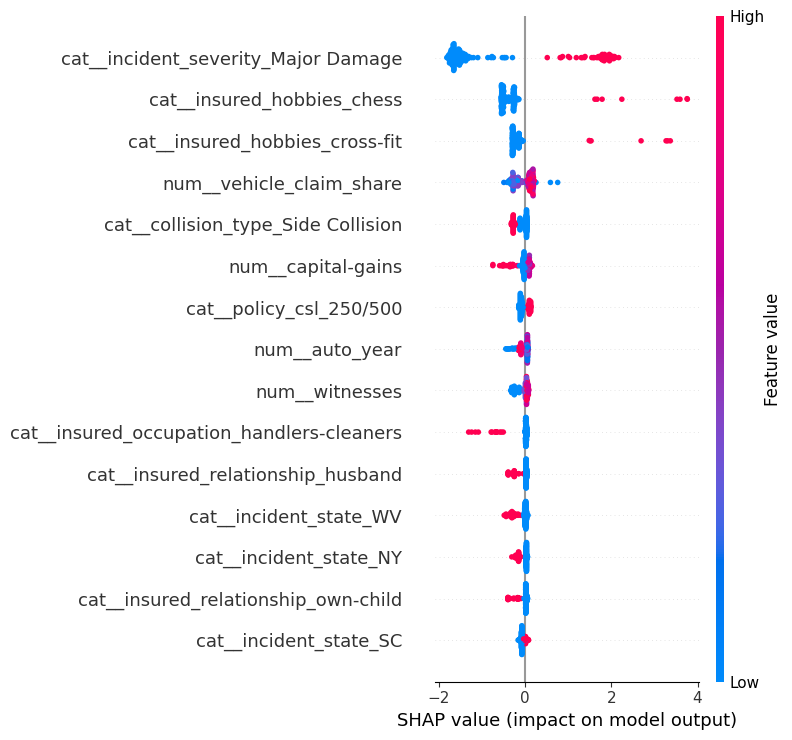

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig = plt.figure(figsize=(8,6))
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout(); plt.show()

**Reading the SHAP summary plot:** each dot is one test claim; color shows whether that feature's value was high (red) or low (blue) for that claim; horizontal position shows whether that feature pushed the prediction toward "fraud" (right) or "not fraud" (left) for that claim.

**Features associated with higher predicted fraud risk (from the plot):** `incident_severity_Major Damage` = 1 (red dots to the right), high `claim_to_premium_ratio`, `no_report_flag` = 1, and the flagged hobby categories.

**Features associated with lower predicted fraud risk:** `incident_severity_Major Damage` = 0 (blue dots pushed left), low claim-to-premium ratio, and having a police report on file.

Again: these are model-learned associations on this dataset, not validated causal drivers.

## Local explanation — one example claim

Highest-risk test claim (row 112): predicted fraud probability = 0.964, actual label = 0


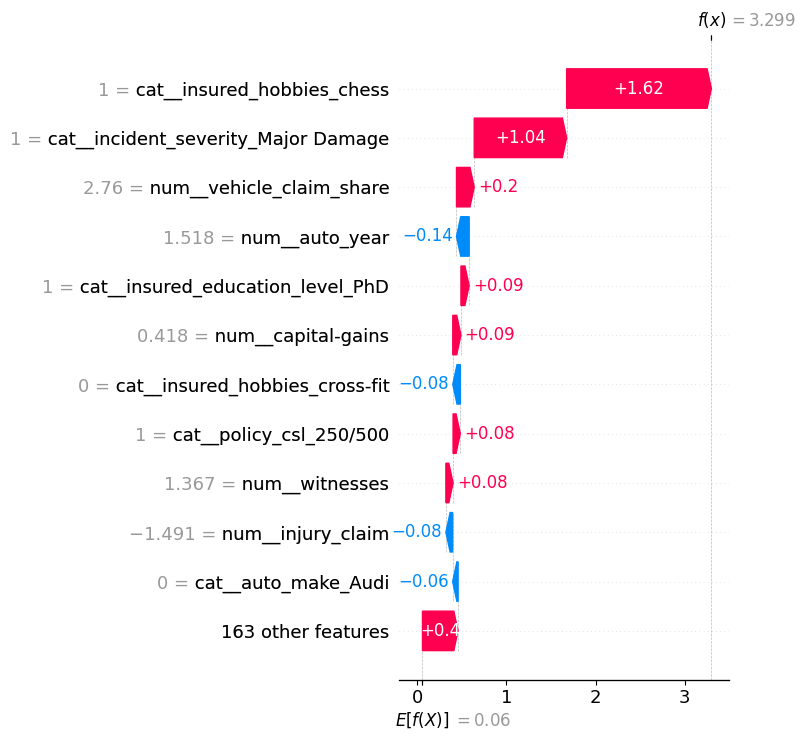

In [4]:
idx = int(np.argmax(model.predict_proba(X_test)[:,1]))
print(f"Highest-risk test claim (row {idx}): predicted fraud probability = {model.predict_proba(X_test)[idx,1]:.3f}, actual label = {y_test.values[idx]}")

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1] if len(np.ravel(base_val)) > 1 else np.ravel(base_val)[0]

fig = plt.figure(figsize=(8,4))
shap.waterfall_plot(shap.Explanation(values=sv[idx], base_values=base_val,
                                      data=X_test[idx], feature_names=feature_names), max_display=12, show=False)
plt.tight_layout(); plt.show()

This is the level of explanation an investigator would actually see for one flagged claim — not just "risk score 0.93," but *which specific factors* pushed that score up or down, in order of impact. That is what makes the score auditable and actionable rather than a black-box number.

## Permutation importance (a second, model-agnostic check)
Native feature importance and SHAP are both computed *from* the fitted model's internal structure. Permutation importance instead measures how much test performance *drops* when a feature's values are randomly shuffled — a useful cross-check that isn't tied to the specific algorithm.

In [5]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring='average_precision')
perm_series = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False).head(10)
perm_series

cat__incident_severity_Major Damage      0.290171
cat__insured_hobbies_chess               0.118837
cat__insured_hobbies_cross-fit           0.052037
cat__insured_hobbies_camping             0.014978
cat__insured_relationship_husband        0.014276
cat__policy_csl_250/500                  0.012812
cat__auto_make_Accura                    0.010902
cat__insured_relationship_own-child      0.009287
num__claim_to_premium_ratio              0.008546
cat__insured_occupation_other-service    0.008313
dtype: float64

**Cross-check result:** `incident_severity_Major Damage` again dominates, confirming (across three different interpretability methods) that this is the model's primary driver — and reinforcing that this magnitude of reliance on one categorical value is worth flagging to a business stakeholder as unusually concentrated, whatever the underlying reason.

## Phase 11 summary — what NOT to conclude
- We can say: the model relies heavily on `incident_severity`, moderately on claim-ratio and reporting-behavior features, and picks up a spurious-looking hobby signal.
- We should **not** say: "chess players commit more fraud," "major damage claims are proof of fraud," or "this model explains *why* fraud happens." It ranks claims by learned statistical association in this specific sample — investigators use that ranking as a starting point for human judgment, not as a verdict.